# Week 2 · Day 1 — From prices to a model that trades

Last week you built *rules*. This week you build *models that learn*. And unlike a
textbook, you won't wait days to find out if your model is any good: **by the end
of this notebook your model will trade on the real backtester, and you'll see its
equity curve against the benchmark.**

You'll build **two** functions today that matter:
1. `predictions_to_weights` — turn a model's guesses into an actual portfolio.
2. `model_to_strategy` — the bridge that lets the backtester *run* your model.

Everything else you already have: the feature table is built from **your week-1
indicators**, and the final scorecard uses **your week-1 charts and metrics**.

## 1. Features — your week-1 indicators, put to work

A model can't read a price chart; it reads a **table of numbers**. Each row is one
day; each column is a *feature* — a signal describing that day. And you already
wrote every one of these last week: the SMA ratio, RSI, and volatility. Building
the feature table is just **stacking your own indicators into columns.**

The label — the thing we predict — is the **next day's return**.

In [ ]:
import sys, os
while not os.path.isdir('src') and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir('..')
sys.path.insert(0, 'src')

import numpy as np, json
import matplotlib.pyplot as plt
os.makedirs('dashboard/data', exist_ok=True)

from tradinglab.data_feed import DataFeed
from tradinglab.features import feature_columns, FEATURE_NAMES

EPOCHS = 150
COMMISSION = 0.00
TOP_K = 4

feed = DataFeed.from_dir('data/egx')
# feed = DataFeed.from_dir('data/egx', symbols=['COMI', 'HRHO', 'TMGH', 'SWDY', 'FWRY', 'ABUK'])
# feed = DataFeed.from_dir('data/egx', symbols=['ABUK'])

X0 = feature_columns(feed, asset=0)   # the feature table for the first stock
print('stock:', feed.symbols[0])
print('columns (your week-1 indicators):', FEATURE_NAMES)
print('a real row (day 100):', np.round(X0[100], 3))

stock: ABUK
columns (your week-1 indicators): ['return', 'p/sma_fast', 'p/sma_slow', 'rsi', 'volatility', 'macd_hist', 'return_5d', 'return_10d', 'volume_ratio']
a real row (day 100): [0.006]


> **Reuse check.** Open `src/tradinglab/features.py` and look at `feature_columns`.
> You'll see it calls `sma`, `rsi`, and `rolling_volatility` — the exact functions
> you wrote and graduated last week. Nothing new; your tools, reused.

## 2. Build the dataset and split it — the habit

We pool every stock's rows into one training table (more examples = a better
model), then split **by time**: train on the earlier period, test on the later one
the model has never seen. That split is the discipline you'll use on every model
this week.

In [28]:
from tradinglab.features import build_pooled_dataset
split_day = int(feed.n_days * 0.7)
X_train, y_train, X_test, y_test = build_pooled_dataset(feed, split_day)
print('train:', len(X_train), '| test:', len(X_test),
      '| split at calendar day', split_day, 'of', feed.n_days)


c:\Users\araslan\Desktop\Projects\internship-algo\efg-algo-internship\src\tradinglab\features.py:64: RuntimeWarning: invalid value encountered in divide
  volume_ratio = volume / vol_avg20


train: 27574 | test: 11798 | split at calendar day 811 of 1159


## 3. Train your first model

The model is a small neural network (an `MLP`). You don't derive it — you **train**
it and, if you like, **extend** it (open `src/tradinglab/models.py`: there's a spot
marked to add a layer). Watch **both** losses: if train keeps dropping while test
flattens, that's *overfitting* — the model memorizing instead of learning.

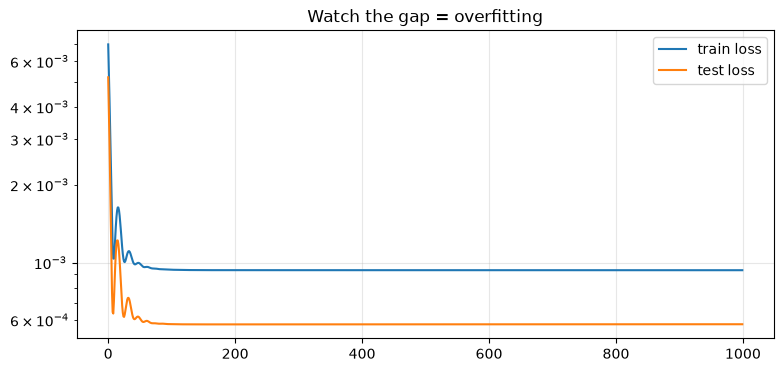

final train 0.00093 | test 0.00058


In [13]:
import torch; torch.manual_seed(0)
from tradinglab.models import MLP, DeepMLP
from tradinglab.ml import train_model

model = MLP(X_train.shape[1], hidden=32)
# model = DeepMLP(X_train.shape[1], hidden=32, n_hidden_layers=2)

history = train_model(model, X_train, y_train, X_test, y_test, epochs=EPOCHS)
plt.figure(figsize=(9,4))
plt.plot(history['train'], label='train loss'); plt.plot(history['test'], label='test loss')
plt.yscale('log')
plt.legend(); plt.grid(alpha=.3); plt.title('Watch the gap = overfitting'); plt.show()
print('final train %.5f | test %.5f' % (history['train'][-1], history['test'][-1]))

## 4. Function 1 — `predictions_to_weights`

A model that predicts numbers isn't a strategy yet. You have to turn its guesses
into a **portfolio**: how much money goes into each stock.

**First, the obvious version:** rank the stocks by predicted return, hold the best
`top_k`, split the money equally. But there's a subtle flaw in that — think about
what happens if the model predicts *every* stock will fall. Ranking still picks the
"least bad" ones and buys them. You'd be buying stocks you expect to *lose* money
on, just because something has to be top-ranked.

**So the real rule:** only hold stocks the model predicts will actually **rise**
(positive predicted return). Among those, take the top `top_k`, equal-weight. If
the model is bearish on everything, hold **nothing** — an all-zero weight vector,
which the simulator treats as a cash day (zero return) rather than a forced loss.

**In:** `predicted_returns` (one guess per stock), `top_k`.
**Out:** weights that are non-negative, sum to 1 (or to 0 if nothing is worth
holding), with at most `top_k` non-zero entries.
**Hint:** `np.where(predicted_returns > 0)[0]` gives the positive-predicted stocks;
rank within those with `np.argsort`.
**Done when:** the checks pass — including the all-negative case.

In [14]:
def predictions_to_weights(predicted_returns, top_k=2):
    n = len(predicted_returns)
    w = np.zeros(n)
    # ---8<--- solution
    positive = np.where(predicted_returns > 0)[0]        # only stocks expected to rise
    if len(positive) == 0:
        return w                                          # bearish on all -> hold cash
    k = min(top_k, len(positive))
    best = positive[np.argsort(predicted_returns[positive])[-k:]]
    w[best] = 1.0 / k
    return w
    # ---8<--- end

# normal case: two positives (0.3, 0.1) held equally
test = predictions_to_weights(np.array([0.1, -0.2, 0.3, 0.05]), top_k=2)
assert abs(test.sum()-1) < 1e-9 and (test>0).sum()==2 and test[2]>0 and test[0]>0
print('normal case ✓  ->', test)

# the flaw we fixed: all-negative predictions -> hold NOTHING, not a forced bet
bearish = predictions_to_weights(np.array([-0.5, -0.1, -0.3]), top_k=2)
assert (bearish == 0).all(), 'should hold cash when nothing is expected to rise'
print('all-bearish case ✓  -> holds cash (all zeros):', bearish)

normal case ✓  -> [0.5 0.  0.5 0. ]
all-bearish case ✓  -> holds cash (all zeros): [0. 0. 0.]


## 5. Function 2 — `model_to_strategy` (the bridge)

This is the function that lets the backtester **run your model**. The backtester
asks a strategy for weights each day by calling `strategy(observation)`, where
`observation` is a window of shape `(n_assets, lookback, n_features)`.

The trick: the **last timestep** of that window, `observation[:, -1, :]`, is exactly
the feature row your model was trained on. So: take that row, predict for every
stock, and convert to weights with the function you just wrote.

**In:** a trained `model` (and `top_k`).
**Out:** a `strategy(observation) -> weights` function the backtester can call.
**Hint:** use `predict(model, feats)` where `feats = observation[:, -1, :]`.
**Done when:** the check produces valid weights from a fake observation.

In [15]:
from tradinglab.ml import predict

def model_to_strategy(model, top_k=2):
    def strategy(observation):
        # ---8<--- solution
        feats = observation[:, -1, :].astype('float32')   # latest features per asset
        preds = predict(model, feats)                      # one prediction per stock
        return predictions_to_weights(preds, top_k)
        # ---8<--- end
    return strategy

fake_obs = np.random.default_rng(0).normal(0, 0.02, (feed.n_assets, 30, X_train.shape[1])).astype('float32')
w = model_to_strategy(model, top_k=2)(fake_obs)

# predictions_to_weights only holds POSITIVE predictions now, so this random fake
# input might not have exactly 2 positive predictions. Check the real contract
# instead: valid weights, non-negative, summing to 0 (cash) or 1, never more than top_k.
assert (w >= 0).all(), 'weights must be non-negative'
assert abs(w.sum() - 1) < 1e-6 or abs(w.sum()) < 1e-6, 'weights must sum to 1, or to 0 if holding cash'
assert (w > 0).sum() <= 2, 'should never hold more than top_k'
print('model_to_strategy correct ✓  -> weights', np.round(w, 3), '| held:', (w>0).sum(), 'stock(s)')

model_to_strategy correct ✓  -> weights [0.  0.  0.5 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 0.  0.  0.  0.  0.  0.  0.  0.5 0.  0.  0.  0.  0.  0.  0.  0. ] | held: 2 stock(s)


## 6. Fire it — run your model on the real backtester

Now the payoff. Wrap your model as a strategy and run it through the **same
backtester you used in week 1**, on the **test period** the model never trained on.
Then read the verdict with `report` — which draws the equity curve using **your
week-1 chart** and prints numbers from **your week-1 metrics**.

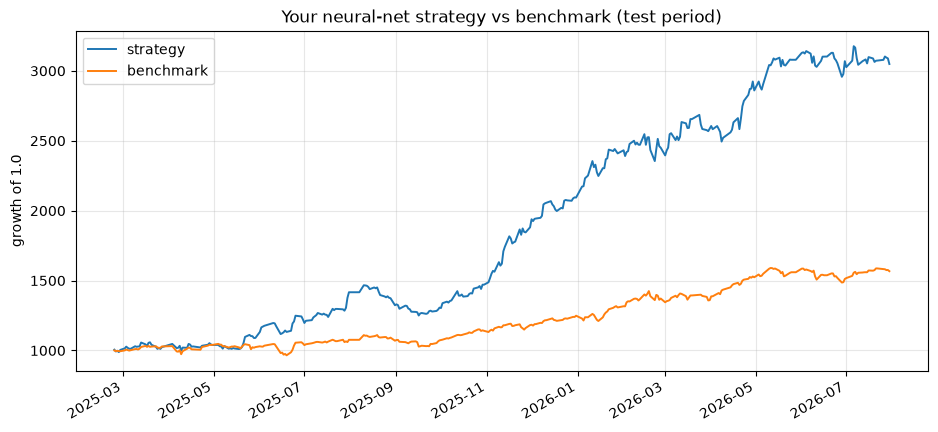

total return   : +204.9%
sharpe         : 3.23
max drawdown   : 14.7%
final value    : 3048.83   (benchmark 1567.20)
beat benchmark : YES
                 you beat the benchmark by 1,482 EGP


In [ ]:
from tradinglab.simulator import PortfolioSimulator
from tradinglab.backtester import run_backtest
from tradinglab.report import report

sim = PortfolioSimulator(feed, commission=COMMISSION)
split = int(feed.n_days * 0.7)                       # test period only = honest
strategy = model_to_strategy(model, top_k=TOP_K)
result = run_backtest(sim, strategy, lookback=30, start=split)

report(result, title='Your neural-net strategy vs benchmark (test period)', start_capital=1000.0)
json.dump({'portfolio':[round(x,4) for x in result['portfolio'].tolist()],
           'benchmark':[round(x,4) for x in result['benchmark'].tolist()]},
          open('dashboard/data/nn_equity.json','w'))

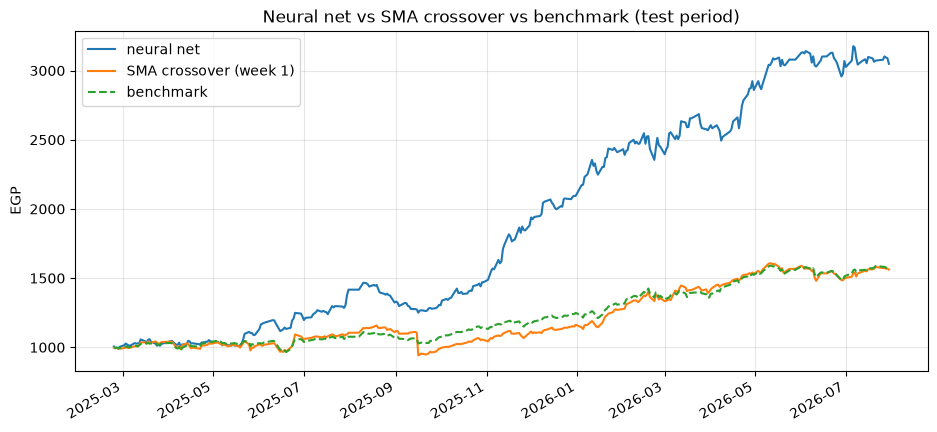

neural net    : 3,049 EGP
SMA crossover : 1,562 EGP
benchmark     : 1,567 EGP


In [17]:
from tradinglab.strategies.sma import sma_crossover_weights   # your week-1 strategy

# run the same trend-following rule, on the same test period, same universe
result_sma = run_backtest(sim, lambda o: sma_crossover_weights(o, 9, 20), lookback=30, start=split)

START = 1000.0
dates = result['dates']   # same date range for both, since same sim/split/lookback

plt.figure(figsize=(11, 5))
plt.plot(dates, result['portfolio'] * START, label='neural net')
plt.plot(dates, result_sma['portfolio'] * START, label='SMA crossover (week 1)')
plt.plot(dates, result['benchmark'] * START, label='benchmark', linestyle='--')
plt.legend(); plt.grid(alpha=0.3); plt.ylabel('EGP')
plt.title('Neural net vs SMA crossover vs benchmark (test period)')
plt.gcf().autofmt_xdate()
plt.show()

print(f"neural net    : {result['portfolio'][-1]*START:,.0f} EGP")
print(f"SMA crossover : {result_sma['portfolio'][-1]*START:,.0f} EGP")
print(f"benchmark     : {result['benchmark'][-1]*START:,.0f} EGP")

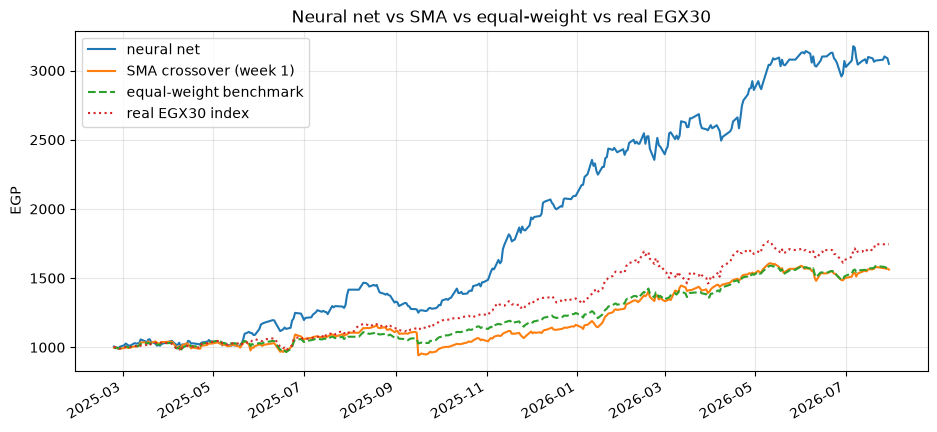

In [18]:
from tradinglab.data_feed import load_egx30_returns

egx30_full = load_egx30_returns('data/egx30.csv', feed.dates)

start_idx = max(split, 30)
end_idx = feed.n_days - 1
egx30_test = egx30_full[start_idx + 1 : end_idx + 1]
egx30_curve = np.cumprod(1 + egx30_test) * START     # <- same START scaling as everything else

plt.figure(figsize=(11, 5))
plt.plot(dates, result['portfolio'] * START, label='neural net')
plt.plot(dates, result_sma['portfolio'] * START, label='SMA crossover (week 1)')
plt.plot(dates, result['benchmark'] * START, label='equal-weight benchmark', linestyle='--')
plt.plot(dates, egx30_curve, label='real EGX30 index', linestyle=':')
plt.legend(); plt.grid(alpha=0.3); plt.ylabel('EGP')
plt.title('Neural net vs SMA vs equal-weight vs real EGX30')
plt.gcf().autofmt_xdate()
plt.show()


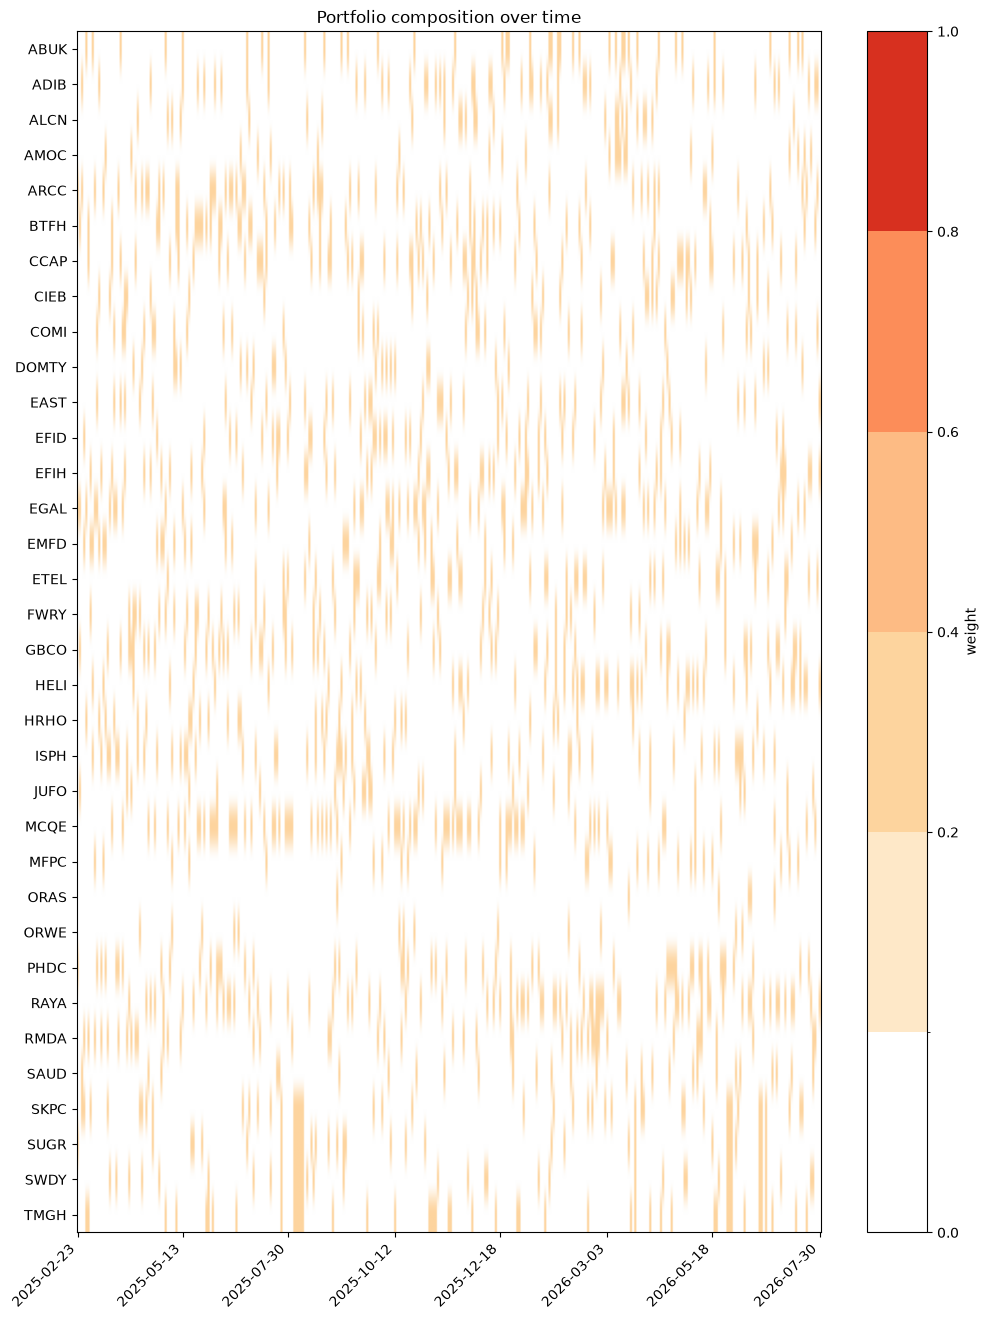

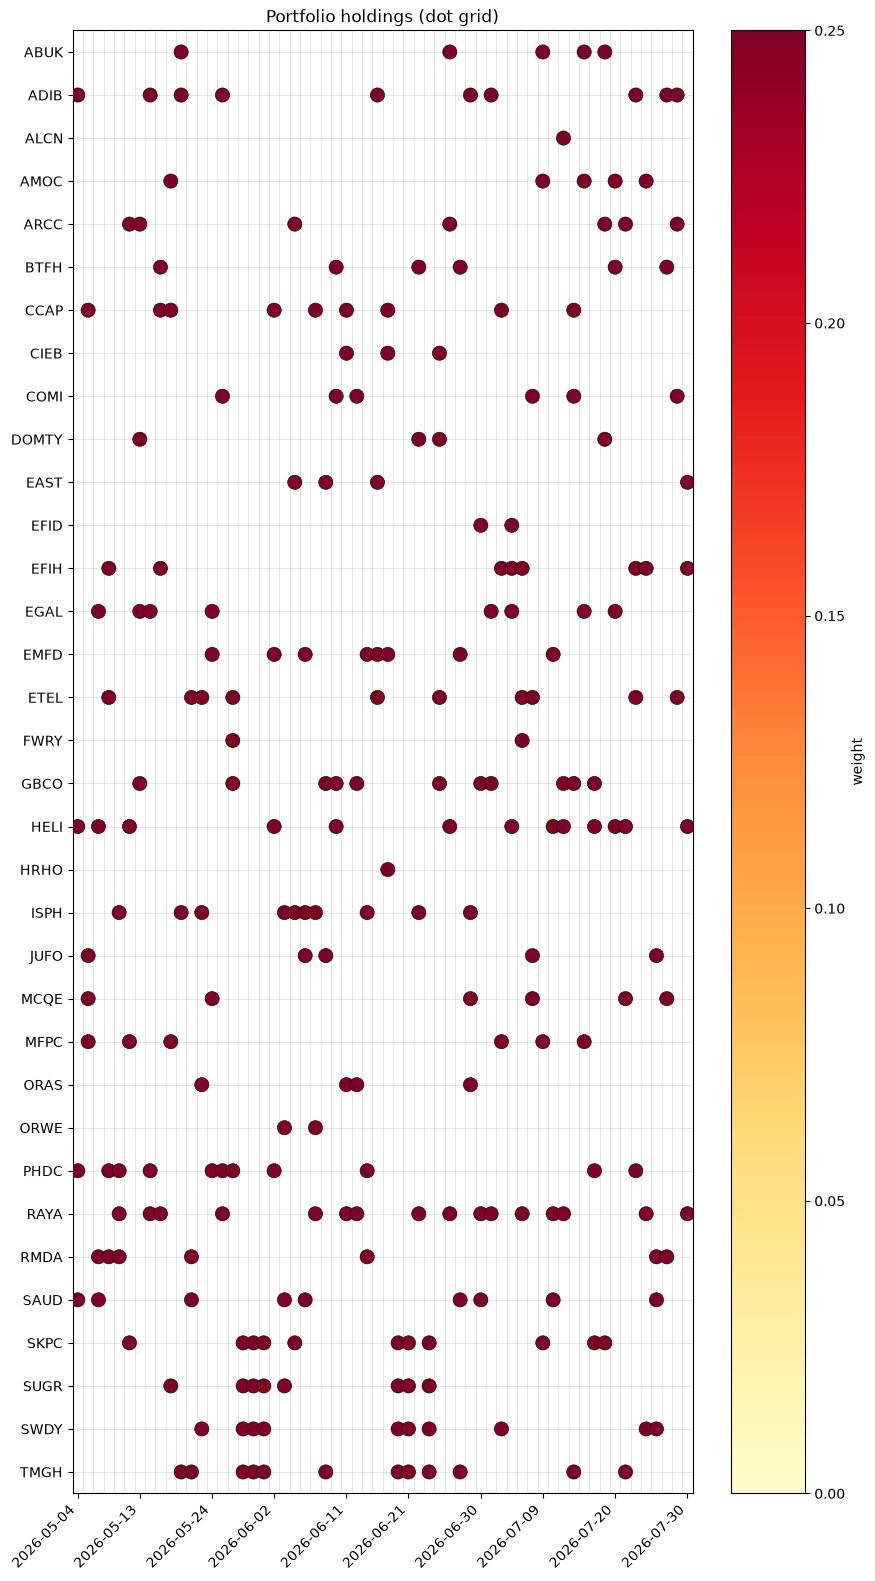

total trades: 2266
avg stocks held: 4.0


In [19]:
from tradinglab.charting import plot_portfolio_composition_discrete, plot_portfolio_dots, turnover_summary

plot_portfolio_composition_discrete(result['weights'], result['dates'], feed.symbols)
plt.show()

# zoom into the last 60 days for the precise dot view
plot_portfolio_dots(result['weights'][-60:], result['dates'][-60:], feed.symbols)
plt.show()


summary = turnover_summary(result['weights'])
print('total trades:', summary['total_trades'])
print('avg stocks held:', summary['avg_stocks_held'])

## 7. Verdict, and what's next

You built a feature table from your own indicators, trained a neural network, turned
it into a strategy, and **watched it trade** — all in one sitting. Look at the
verdict: did it beat the benchmark? Probably not by much, and maybe not at all.

**Hold that feeling.** You'll build better models this week — an LSTM tomorrow — and
they won't obviously do better either. That isn't failure, and on day 4 you'll learn
exactly what it means. For now, you've done the real loop of quantitative work:
**build → backtest → report → judge honestly.**

**Graduate your two functions** into `src/tradinglab/strategies/predictor.py`, then:
`uv run pytest week2/tests/`